In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams.update({
    "text.usetex": True,
    "font.size": 14
})

# Task 1 - Gradient Descent

## Simple quadratic function and its minimiser

For the simple quadratic function we seek a minimizer of:

$$
f(x) = g(Rx), \quad \text{with} \quad g(y_1,y_2) = \sqrt{b}y_1^2 + 2y_2^2
$$

and a rotation matrix given by

$$
R = \begin{pmatrix}
\cos\phi & \sin\phi \\
-\sin\phi & \cos\phi
\end{pmatrix}
$$

### Minimise $g$ analytically

First minimise in the $y$-coordinates.

$$
g(y) = \sqrt{b}y_1^2 + 2y_2^2
$$

the gradient is defined:

$$
\nabla g(y) = \begin{pmatrix}
2\sqrt{b} y_1 \\
4y_2
\end{pmatrix}
$$

Setting $\nabla g(y) =0$ implies:

$$
2\sqrt{b}y_1 = 0 \Rightarrow y_1 = 0 \qquad 4y_2 = 0 \Rightarrow y_2 = 0
$$

So the **only stationary point** is:

$$
y^* = (0,0)^T.
$$

Consider the Hessian matrix:

$$
\nabla^2 g(y) = \begin{pmatrix}
2\sqrt{b} & 0 \\
0 & 4
\end{pmatrix}
$$

which has positive diagonal entries (since $b>0$), so it is positive definite. This implies $y^* = 0 $ is the unique minimiser of g.

### Transform back to $x$-coordinates

We have $y=Rx$, so:

$$
f(x) = g(Rx).
$$

Since R is a rotation, it is orthogonal and invertible. The minimum of $f$ occurs when $Rx$ equals the minimiser of $g$:

$$
Rx^* = y^* = 0 \Rightarrow x^* = R^{-1}0 = 0.
$$

So analytically, the minimiser of the simple quadratic is:

$$
\boxed{
    x^* = (0,0)^T
}
$$

for any angle $\phi$ and any $b> 0$

### Matrix form

write:

$$
g(y) = y^T D y , \quad D = \begin{pmatrix}
\sqrt{b} & 0 \\
0 & 2
\end{pmatrix}
$$

Then 

$$
f(x) = g(Rx) = (Rx)^TD(Rx) = x^T(R^TDR)x = x^TQx
$$

where 

$$
Q = R^TDR
$$

is symmetric positive definite.

Then 

$$
\nabla f(x) = 2Qx, \qquad \nabla^2f(x) = 2Q.
$$

Setting $\nabla f(x) =0$ gives $Qx = 0 \Rightarrow x=0$ (since Q is invertible).

This is the form which will be used to derive the **exact optimal step size** in steepest descent for this quadratic:

$$
\alpha_k^* = \frac{||\nabla f(x_k)||^2}{\nabla f(x_k)^TQ\nabla f(x_k)}
$$

In [2]:
import numpy as np

def rotation(phi):
    return np.array([
        [np.cos(phi), np.sin(phi)],
        [-np.sin(phi), np.cos(phi)]
    ])

def g(y, b):
    return np.sqrt(b) * y[0]**2 + 2 * y[1]**2

def grad_g(y, b):
    return np.array([
        2*np.sqrt(b)*y[0],
        4*y[1]
    ])

def f_quad(x, b, phi):
    R = rotation(phi)
    y = R @ x
    return g(y, b)

def grad_f_quad(x, b, phi):
    R = rotation(phi)
    y = R @ x
    return R.T @ grad_g(y, b)

## Rosenbrock function and its minimiser 

Consider the 2D Rosenbrock function:

$$
f(x,y) = (a-x)^2 + b(y-x^2)^2
$$

with parameters $a \in \mathbb{R}$ and $b>0$

### Gradient

Compute the martial derivatives:

$$
\frac{\partial f}{\partial x} = 2(x-a) -4bx(y-x^2), \qquad \frac{\partial f}{\partial y} = 2b(y-x^2)
$$

Hence the gradient of $f$ is:

$$
\nabla f(x,y) = \begin{pmatrix}
2(x-a) -4bx(y-x^2) \\
2b(y-x^2)
\end{pmatrix}
$$

### Stationary points

Stationary points satisfy $\nabla f(x,y) = 0$. Hence:

$$
\begin{align}
2(x-a) -4bx(y-x^2) &= 0 \\
2b(y-x^2) &= 0
\end{align}
$$

From the second equation:

$$
2b(y-x^2) \Rightarrow y = x^2
$$

Substituting this into the first equation:

$$
2(x-a) -4bx(y-x^2) = 2(x-a) = 0.
$$

Hence $x=a$ and there is a single stationary point at:

$$
\boxed{
    (x^*, y^*) = (a, a^2) = (1,1)
}
$$

### Nature of the stationary point

The Hessian of the Rosenbrock function at the stationary point is:

$$
H(x^*, y^*) = \begin{pmatrix}
2+8ba^2 & -4bx \\
-4bx & 2b 
\end{pmatrix}
$$

To determine the nature of the stationary point we check positive definiteness. The leading principal minor is

$$
\Delta_1 = 2 + 8ba^2 > 0 \quad \text{for } b>0,
$$
and the determinant is

$$
\Delta_2 = \det H(x^*,y^*)
= (2 + 8ba^2)(2b) - (-4ba)^2
= 4b + 16b^2a^2 - 16b^2a^2
= 4b > 0.
$$

Since both $\Delta_1 >0$ and $\Delta_2 >0 $ for all $b>0$, the Hessian is positive definite at $(x^*,y^*)$. Therefore $(x^*,y^*) = (a,a^2)$ is a **strict local minimum**.

Furthermore, $f(x,y) \to \infty$ as $|(x,y)| \to \infty$ and this is the only stationary point of the Rosenbrock function, so $(a,a^2)$ is the **unique global minimiser**. In the standard case $(a=1)$, this gives a global minimum at $(1,1)$.


In [3]:
def f_rosen(x, b):
    return (1 - x[0])**2 + b*(x[1] - x[0]**2)**2

def grad_f_rosen(x, b):
    x1, x2 = x
    df_dx = 2*(x1 - 1) - 4*b*x1*(x2 - x1**2)
    df_dy = 2*b*(x2 - x1**2)
    return np.array([df_dx, df_dy])

In [4]:
def gradient_descent(f, grad_f, x0, alpha_rule,
                     maxiter=10_000, tol_grad=1e-3, tol_step=1e-5):
    
    x = x0.copy()
    history = [x.copy()]
    stop_reason = None

    for k in range(maxiter):
        g = grad_f(x)
        gnorm = np.linalg.norm(g)
        if gnorm < tol_grad:
            stop_reason = "grad_tol"
            break

        alpha = alpha_rule(k, x, g)
        x_new = x - alpha * g
        step_norm = np.linalg.norm(x_new - x)
        history.append(x_new.copy())

        if step_norm < tol_step:
            stop_reason = "step_tol"
            x = x_new
            break

        x = x_new

    if stop_reason is None:
        stop_reason = "maxiter" if k + 1 >= maxiter else "unknown"

    return x, np.array(history), stop_reason

## Step size rules 

Implement three specific $\alpha$ rules:

1) **Fixed step size.**
2) **Golden-Section line search**
3) **Nesterov acceleration**

### Fixed step size

A constant step size $\alpha_k = L$ is used for every iteration. 

Choosing $L$ too large leads to divergence or oscillations (zig-zagging), while choosing it too small drastically slows the convergence.



In [5]:
def alpha_fixed(L):
    return lambda k, x, g: L

### Golden Section line search

Here $\alpha_k$ is chosen by approximately minimising the one dimensional function:

$$
\phi(\alpha) = f(x_k - \alpha \nabla f(x_k))
$$

along the search direction. 

GSS provides a derivative free way of performing this using bisection methods that ensure a monotone decrease in $f$.


In [6]:
def golden_section_search(phi, a=0.0, b=1.0, tol=1e-5):
    w = (np.sqrt(5) - 1) / 2  # golden ratio constant
    c = b - w*(b - a)
    d = a + w*(b - a)
    fc, fd = phi(c), phi(d)

    while abs(b - a) > tol:
        if fc < fd:
            b, d, fd = d, c, fc
            c = b - w*(b - a)
            fc = phi(c)
        else:
            a, c, fc = c, d, fd
            d = a + w*(b - a)
            fd = phi(d)

    return (a+b)/2

def alpha_gss(f):
    def rule(k, x, g):
        phi = lambda a: f(x - a * g)
        return golden_section_search(phi)
    return rule

### Nesterov acceleration

This method uses a momentum based update of the form:

$$
v_{k+1} = x_k - \alpha_k \nabla f(x_k), \qquad x_{k+1} = v_{k+1} + \frac{k}{k+3} (v_{k+1}-v_k),
$$

using a fixed step size $\alpha_k = L$.


In [7]:
def nesterov_descent(f, grad_f, x0, L,
                     maxiter=10000, tol_grad=1e-3, tol_step=1e-5):

    x = x0.copy()
    v = x0.copy()
    history = [x.copy()]
    stop_reason = None

    for k in range(maxiter):
        g = grad_f(x)
        if np.linalg.norm(g) < tol_grad:
            stop_reason = "grad_tol"
            break

        v_new = x - L*g
        x_new = v_new + (k/(k+3))*(v_new - v)

        if np.linalg.norm(x_new - x) < tol_step:
            stop_reason = "step_tol"
            x = x_new
            break

        v = v_new
        x = x_new
        history.append(x.copy())

    if stop_reason is None:
        stop_reason = "maxiter" if k + 1 >= maxiter else "unknown"

    return x, np.array(history), stop_reason

## Plotting functions 

The functions in the cell below are used for visualising both tasks 1 and 2.

They generate contour plots of the objective function in $\mathbb{R}^2$ and plot the optimisation paths produced by the different gradient descent methods.

- `plot_contour_with_paths()`: Plots level sets of an unconstrained 2D objective together with one or more optimisation paths.
- `plot_box()`: Draws the rectangular box constraint $[x_L, x_R]$ for the penalty method in task 2.
- `plot_penalty_paths()`: Visualises the sequence of paths obtained during the penalty continuation for increasing values of $\mu$, showing how the iterates are driven to the feasible region.

In [ ]:
def plot_contour_with_paths(f, paths, labels, xlim, ylim, title="", n_levels=40):
    """
    f      : function R^2 -> R
    paths  : list of arrays, each shape (K_i, 2)
    labels : list of labels for each path
    """
    # Grid
    x1 = np.linspace(xlim[0], xlim[1], 400)
    x2 = np.linspace(ylim[0], ylim[1], 400)
    X1, X2 = np.meshgrid(x1, x2)
    Z = np.zeros_like(X1)

    # Evaluate f on grid
    for i in range(X1.shape[0]):
        for j in range(X1.shape[1]):
            Z[i, j] = f(np.array([X1[i, j], X2[i, j]]))

    # Contour lines 
    fig, ax = plt.subplots(figsize=(6, 5))
    cs = ax.contour(X1, X2, Z, levels=n_levels, linewidths=0.7)
    ax.clabel(cs, inline=True, fontsize=8)

    # Plot all paths
    for path, lab in zip(paths, labels):
        ax.plot(path[:, 0], path[:, 1], "o-", markersize=4, linewidth=1.5, label=lab)
        ax.plot(path[0, 0], path[0, 1], "s", markersize=7)
        ax.plot(path[-1, 0], path[-1, 1], "*", markersize=10)

    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.set_title(title)
    ax.legend(loc="upper left", framealpha=0.9)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal", "box")
    

    plt.tight_layout()
    plt.show()

def plot_box(ax, xL, xU, **kwargs):
    """Draw the rectangle [xL, xU] on the given axes."""
    xs = [xL[0], xU[0], xU[0], xL[0], xL[0]]
    ys = [xL[1], xL[1], xU[1], xU[1], xL[1]]
    ax.plot(xs, ys, **kwargs)

def plot_penalty_paths(f, paths_mu, mus, xL, xU, xlim, ylim,
                       title="", n_levels=40):
    """
    f         : original objective (R^2 -> R)
    paths_mu  : list of arrays, each (K_l, 2) path for a given μ_l
    mus       : list of μ_l values, same length as paths_mu
    xL, xU    : lower/upper bounds for the box
    xlim,ylim : plotting window
    """

    # Grid for contours
    x1 = np.linspace(xlim[0], xlim[1], 400)
    x2 = np.linspace(ylim[0], ylim[1], 400)
    X1, X2 = np.meshgrid(x1, x2)
    Z = np.zeros_like(X1)

    for i in range(X1.shape[0]):
        for j in range(X1.shape[1]):
            Z[i, j] = f(np.array([X1[i, j], X2[i, j]]))

    fig, ax = plt.subplots(figsize=(6, 5))

    # Contour lines of f
    cs = ax.contour(X1, X2, Z, levels=n_levels, linewidths=0.7)
    ax.clabel(cs, inline=True, fontsize=8)

    # Draw the box
    plot_box(ax, xL, xU, color="k", linestyle="--", linewidth=1.5)

    # Plot paths for each μ
    for path, mu in zip(paths_mu, mus):
        ax.plot(path[:, 0], path[:, 1],
                "o-", markersize=3, linewidth=1.5,
                label=rf"$\mu={mu:g}$")
        ax.plot(path[0, 0], path[0, 1], "s", markersize=6)   # start
        ax.plot(path[-1, 0], path[-1, 1], "*", markersize=9) # end

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.set_title(title)
    ax.set_aspect("equal", "box")
    ax.legend(loc="upper left", framealpha=0.9)

    plt.tight_layout()
    plt.show()


## Fixed Step Size Gradient Descent

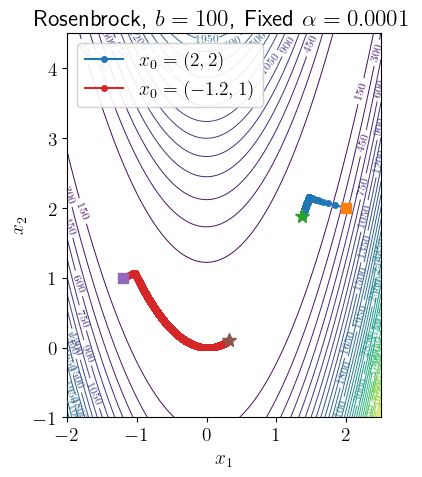

Fixed α Rosenburg (x0 = [2,2])    xmin = [1.37399294 1.88905855] iters = 10000 stop reason = maxiter distance to min = 0.9645184369602444
Fixed α Rosenburg (x0 = [-1.2,1]) xmin = [0.32258787 0.10097506] iters = 10000 stop reason = maxiter distance to min = 1.1256700437141667


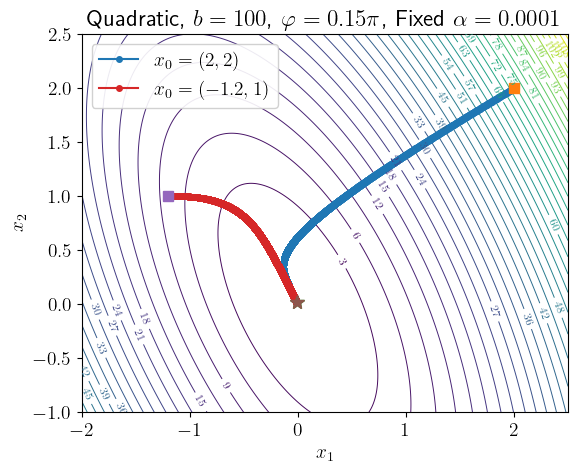

Fixed α Quadratic (x0 = [2,2])    xmin = [-0.01134439  0.02226472] iters = 8885 stop reason = step_tol distance to min = 0.024988258501439452
Fixed α Quadratic (x0 = [-1.2,1]) xmin = [-0.01192927  0.02341251] iters = 10000 stop reason = maxiter distance to min = 0.026276469808737556


In [66]:
# Rosenbrock, Fixed α
b = 100
L = 1e-4 

f    = lambda x: f_rosen(x, b=b)
grad = lambda x: grad_f_rosen(x, b=b)

           
alpha = alpha_fixed(L)

x0_a = np.array([2.0, 2.0])
x0_b = np.array([-1.2, 1.0])

xmin_a, path_a, stop_reason_rosen1 = gradient_descent(f, grad, x0_a, alpha)
xmin_b, path_b, stop_reason_rosen2 = gradient_descent(f, grad, x0_b, alpha)

plot_contour_with_paths(
    f,
    paths=[path_a, path_b],
    labels=[r"$x_0 = (2,2)$", r"$x_0 = (-1.2,1)$"],
    xlim=(-2.0, 2.5),
    ylim=(-1.0, 4.5),
    title=rf"Rosenbrock, $b={b}$, Fixed $\alpha = {L}$"
)

# Calculate distance fronm true minimizer
dist_min_a = np.linalg.norm(xmin_a - np.array([1.0, 1.0]))
dist_min_b = np.linalg.norm(xmin_b - np.array([1.0, 1.0]))

print("Fixed α Rosenburg (x0 = [2,2])    xmin =", xmin_a, "iters =", len(path_a) - 1, "stop reason =", stop_reason_rosen1, "distance to min =", dist_min_a)
print("Fixed α Rosenburg (x0 = [-1.2,1]) xmin =", xmin_b, "iters =", len(path_b) - 1, 'stop reason =', stop_reason_rosen2, "distance to min =", dist_min_b)

# Quadratic, Fixed α
phi = 0.15 * np.pi

f    = lambda x: f_quad(x, b=b, phi=phi)
grad = lambda x: grad_f_quad(x, b=b, phi=phi)
          

x0_a = np.array([2.0, 2.0])
x0_b = np.array([-1.2, 1.0])

xmin_a, path_a, stop_reason_qubic1 = gradient_descent(f, grad, x0_a, alpha)
xmin_b, path_b, stop_reason_qubic2 = gradient_descent(f, grad, x0_b, alpha)

plot_contour_with_paths(
    f,
    paths=[path_a, path_b],
    labels=[r"$x_0 = (2,2)$", r"$x_0 = (-1.2,1)$"],
    xlim=(-2.0, 2.5),
    ylim=(-1.0, 2.5),
    title=rf"Quadratic, $b={b}$, $\varphi=0.15\pi$, Fixed $\alpha = {L}$"
)

# Calculate distance fronm true minimizer
dist_min_a = np.linalg.norm(xmin_a - np.array([0.0, 0.0]))
dist_min_b = np.linalg.norm(xmin_b - np.array([0.0, 0.0]))

print("Fixed α Quadratic (x0 = [2,2])    xmin =", xmin_a, "iters =", len(path_a) - 1, "stop reason =", stop_reason_qubic1, "distance to min =", dist_min_a)
print("Fixed α Quadratic (x0 = [-1.2,1]) xmin =", xmin_b, "iters =", len(path_b) - 1,"stop reason =", stop_reason_qubic2, "distance to min =", dist_min_b)

### Analysis of Results

This section discusses the behaviour of fixed step size gradient descent using a step size $\alpha = 10^{-4}$ on the quadratic and Rosenbrock problems for both $b=1$ and $b=100$.

Across all cases, the fixed step rule shows strong sensitivity to the conditioniing of the landcape and typically requires very large iteration counts, hitting the maximum number of iterations $(10,000)$ in the majority of cases.

**Quadratic, $b=100$**

- for $x_0 = (-1.2,1)$, the run terminates via **step tolerance** after 8800 iterations, meaning updates become tiny before the gradient norm is sufficiently small.
- for $x_0=(2,2)$, the run terminates at the maximum iteration count without reaching the minimiser
- Both trajectories show curvature induced bending. The method slowly follows the valley floor but can't contact quickly in the narrow direction.
- Final distances to the minimiser $(\approx 0.025)$ remain non-negligible.

**Rosenbrock, $b=1$**

On Rosenbrock, with $b=1$, the valley is narrow and curved so the fixed step rule struggles:
- Both runs hit the iteration limit, failing to reach the neighbourhood of $(1,1)$.
- Distances to the optimum remain large [$\approx 0.97$ for $x_0 = (-1.2,1)$ and $\approx 0.74$ for $x_0=(2,2)$].

The method repeatedly crosses the valley instead of following it because the step size is not adapted to the rapidly changing curvature.


**Rosenbrock, $b=100$ (ill-conditioned)**

This is the most ill conditioned problem, and fixed step size performs the worst:
- Both runs hit maxiter, making negligible progress towards $(1,1)$.
- The paths visibly drift into shallow regions and stall.
- The final distances to the minimum [$\approx 0.96$ for $x_0 = (-1.2,1)$ and $\approx 1.12$ for $x_0=(2,2)$] shows the method effectively stops moving long before max iterations are reached

The method cannot follow the Rosenbrock valley because the curvature mismatch becomes extreme, and the constant step size cannot adapt.


**Note**: Parameter `b` can be varied to visualise different problems

### Conclusion

Across all test problems, the fixed step size method shows:

- **Slow convergence**, often requiring the maximum number of iterations.
- **Premature stalling** due to the curvature mismatch.
- **Failure to approach the minimiser** on any of the Rosenbrock tests.
- **Sensity to conditioning**, with performance degrading between $b=1$ and $b=100$ for the Rosenbrock tests.

Without a suitable step size strategy, even simple descent directions may fail on ill-conditioned landscapes.

## Golden Section Search (GSS)

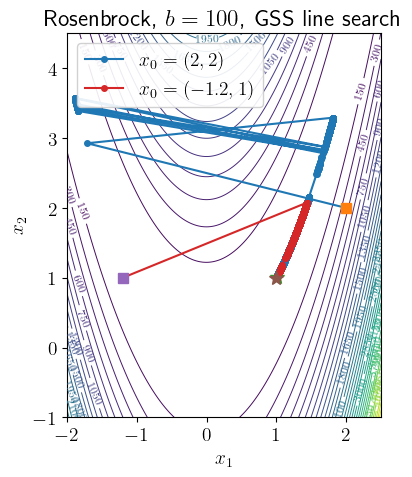

GSS (x0 = [2,2])    xmin = [1.00431069 1.00865187] iters = 8245 stop reason = step_tol distance to min = 0.009666276033858731
GSS (x0 = [-1.2,1]) xmin = [1.00122239 1.00245089] iters = 1244 stop reason = step_tol distance to min = 0.0027388124445360605


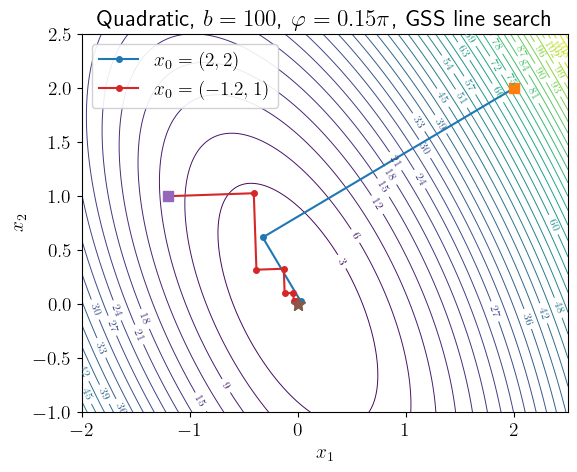

GSS Quadratic (x0 = [2,2])    xmin = [-5.73053430e-05  1.08931865e-04] iters = 5 stop reason = grad_tol distance to min = 0.00012308555368003774
GSS Quadratic (x0 = [-1.2,1]) xmin = [-4.45914552e-05  1.12241703e-04] iters = 17 stop reason = grad_tol distance to min = 0.0001207749878825624


In [72]:
b = 100

# Rosenbrock

f    = lambda x: f_rosen(x, b=b)
grad = lambda x: grad_f_rosen(x, b=b)

alpha = alpha_gss(f)   
x0_a = np.array([2.0, 2.0])
x0_b = np.array([-1.2, 1.0])

xmin_a, path_a, stop_reason_rosen1 = gradient_descent(f, grad, x0_a, alpha)
xmin_b, path_b, stop_reason_rosen2 = gradient_descent(f, grad, x0_b, alpha)

plot_contour_with_paths(
    f,
    paths=[path_a, path_b],
    labels=[r"$x_0 = (2,2)$", r"$x_0 = (-1.2,1)$"],
    xlim=(-2.0, 2.5),
    ylim=(-1.0, 4.5),
    title=rf"Rosenbrock, $b={b}$, GSS line search"
)

# Calculate distance fronm true minimizer
dist_min_a = np.linalg.norm(xmin_a - np.array([1.0, 1.0]))
dist_min_b = np.linalg.norm(xmin_b - np.array([1.0, 1.0]))

print("GSS (x0 = [2,2])    xmin =", xmin_a, "iters =", len(path_a) - 1, "stop reason =", stop_reason_rosen1, "distance to min =", dist_min_a)
print("GSS (x0 = [-1.2,1]) xmin =", xmin_b, "iters =", len(path_b) - 1, "stop reason =", stop_reason_rosen2, "distance to min =", dist_min_b)

# Quadratic 
phi = 0.15 * np.pi

f    = lambda x: f_quad(x, b=b, phi=phi)
grad = lambda x: grad_f_quad(x, b=b, phi=phi)

alpha = alpha_gss(f)  

x0_a = np.array([2.0, 2.0])
x0_b = np.array([-1.2, 1.0])

xmin_a, path_a, stop_reason_qubic1 = gradient_descent(f, grad, x0_a, alpha)
xmin_b, path_b, stop_reason_qubic2 = gradient_descent(f, grad, x0_b, alpha)

plot_contour_with_paths(
    f,
    paths=[path_a, path_b],
    labels=[r"$x_0 = (2,2)$", r"$x_0 = (-1.2,1)$"],
    xlim=(-2.0, 2.5),
    ylim=(-1.0, 2.5),
    title=rf"Quadratic, $b={b}$, $\varphi=0.15\pi$, GSS line search"
)

# Calculate distance fronm true minimizer
dist_min_a = np.linalg.norm(xmin_a - np.array([0.0, 0.0]))
dist_min_b = np.linalg.norm(xmin_b - np.array([0.0, 0.0]))

print("GSS Quadratic (x0 = [2,2])    xmin =", xmin_a, "iters =", len(path_a) - 1, "stop reason =", stop_reason_qubic1, "distance to min =", dist_min_a)
print("GSS Quadratic (x0 = [-1.2,1]) xmin =", xmin_b, "iters =", len(path_b) - 1, "stop reason =", stop_reason_qubic2, "distance to min =", dist_min_b)

### Analysis of Results

GSS adapts the step size at each iteration by approximately minimising the 1D line search function

$$
\phi(\alpha) = f(x_k - \alpha \nabla f(x_k))
$$

which gurantees a monotonic decrease of the objective function. GSS consistently outperforms both fixed step size and Nesterov acceleration across the test problems.

**Quadratic, b=100**

- Both runs reach the minimiser within **5-17 iterations**.
- Stopping reason is the gradient tolerance.
- Final distances to the minimiser are $\approx 10^{-4}$, showing high accuracy.

Zig-zagging is present, however it doesnt affect the time taken to reach the minimiser. This shows that GSS successfully adapts its step size to the curvature, unlike fixed step size which stalled or hit the iteration limit in this case.

**Rosenbrock, b=1**

Rosenbrock's function introduces strong curvature and a narrow curved valley, however GSS still converges in a small number of steps:
- For $x_0 = (2,2)$, the path included **85 iterations** and stopped due to the gradient tolerance.
- For $x_0 = (-1.2,1)$, the path included **69 iterations** and stopped due to the gradient tolerance.
- Both final distances to the minimiser are of order $\approx 10^{-3}$.

The paths demonstrate constrolled progress along the valley without instability or divergence. This confirms the robustness of GSS even on a non-convex objective.

**Rosenbrock, b=100 (ill-conditioned)**

This is the hardest test as the valley is extremely steep in one direction and shallow in the other. Despite this, GSS still converges, although more iterations are required.

- $x_0 = (2,2)$: **8245 iterations**.
- $x_0 = (-1.2,1)$: **1244 iterations**.
- Both runs eventually find points close to $(1,1)$, with distances $\approx 10^{-3}$
- Both runs terminate due to the step tolerance instead of the gradient tolerance. This means the gradient is small enough, but curvature forces extremely small steps.

Even in this extreme scenario, GSS outperforms fixed step size and Nesterov acceleration, both of which stalled early or never reached the valley floor.


**Note**: Parameter b can be varied to visualise different problems

### Conclusion

Across all functions and conditioning levels, GSS shows:

- **Monotonic convergence**.
- **Very small final errors**.
- **Correct stopping due to gradient tolerance or small step sizes**.

It handles difficult curvature far better than the fixed step size and avoids the instability and oscillatory behaviour seen in Nesterov acceleration.

## Nesterov Accelerated Gradient Descent

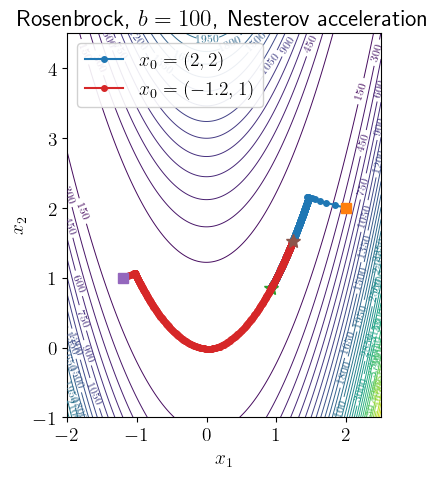

Nesterov (x0 = [2,2])   xmin = [0.92082641 0.8475891 ] iters = 904 stop reason = step_tol distance to min = 0.1717484794294743
Nesterov (x0 = [-1.2,1]) xmin = [1.23296376 1.52101109] iters = 606 stop reason = step_tol distance to min = 0.5707229308578484


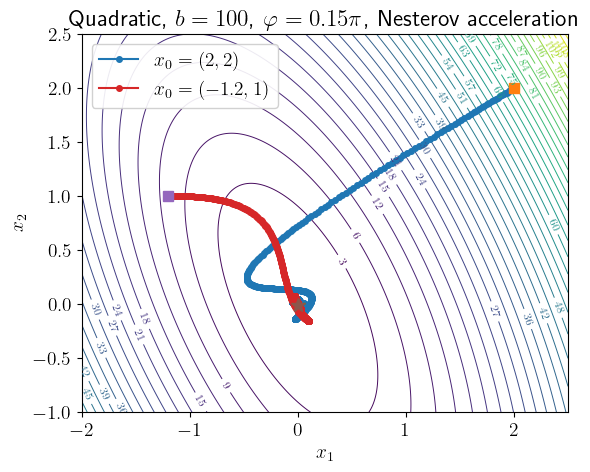

Nesterov (x0 = [2,2])   xmin = [ 0.00128316 -0.00615682] iters = 1523 stop reason = step_tol distance to min = 0.006289113181527284
Nesterov (x0 = [-1.2,1]) xmin = [ 0.00486581 -0.00871709] iters = 1524 stop reason = step_tol distance to min = 0.009983174046770835


In [77]:
b = 100
L = 1e-4

# Rosenbrock

f = lambda x: f_rosen(x, b=b)
grad = lambda x: grad_f_rosen(x, b=b)



x0_a = np.array([2.0, 2.0])
x0_b = np.array([-1.2, 1.0])

xmin_a, path_a, stop_reason_rosen1 = nesterov_descent(f, grad, x0_a, L)
xmin_b, path_b, stop_reason_rosen2 = nesterov_descent(f, grad, x0_b, L)


plot_contour_with_paths(
    f,
    paths=[path_a, path_b],
    labels=[r"$x_0 = (2,2)$", r"$x_0 = (-1.2,1)$"],
    xlim=(-2.0, 2.5),
    ylim=(-1.0, 4.5),
    title=rf"Rosenbrock, $b={b}$, Nesterov acceleration"
)

# Calculate distance fronm true minimizer
dist_min_a = np.linalg.norm(xmin_a - np.array([1.0, 1.0]))
dist_min_b = np.linalg.norm(xmin_b - np.array([1.0, 1.0]))

print("Nesterov (x0 = [2,2])   xmin =", xmin_a, "iters =", len(path_a) - 1, "stop reason =", stop_reason_rosen1, "distance to min =", dist_min_a)
print("Nesterov (x0 = [-1.2,1]) xmin =", xmin_b, "iters =", len(path_b) - 1, "stop reason =", stop_reason_rosen2, "distance to min =", dist_min_b)

# Quadratic

phi = 0.15 * np.pi
f = lambda x: f_quad(x, b=b, phi=phi)
grad = lambda x: grad_f_quad(x, b=b, phi=phi)


x0_a = np.array([2.0, 2.0])
x0_b = np.array([-1.2, 1.0])

xmin_a, path_a, stop_reason_qubic1 = nesterov_descent(f, grad, x0_a, L)
xmin_b, path_b, stop_reason_qubic2 = nesterov_descent(f, grad, x0_b, L)


plot_contour_with_paths(
    f,
    paths=[path_a, path_b],
    labels=[r"$x_0 = (2,2)$", r"$x_0 = (-1.2,1)$"],
    xlim=(-2.0, 2.5),
    ylim=(-1.0, 2.5),
    title=rf"Quadratic, $b={b}$, $\varphi=0.15\pi$, Nesterov acceleration"
)

# Calculate distance fronm true minimizer
dist_min_a = np.linalg.norm(xmin_a - np.array([0.0, 0.0]))
dist_min_b = np.linalg.norm(xmin_b - np.array([0.0, 0.0]))

print("Nesterov (x0 = [2,2])   xmin =", xmin_a, "iters =", len(path_a) - 1, "stop reason =", stop_reason_qubic1, "distance to min =", dist_min_a)
print("Nesterov (x0 = [-1.2,1]) xmin =", xmin_b, "iters =", len(path_b) - 1, "stop reason =", stop_reason_qubic2, "distance to min =", dist_min_b)

### Analysis of Results

Nesterov's accelerated gradient method introduces a momentum term intended to speed up convergence on smooth convex problems.

$$
v_{k+1} = x_k - \alpha_k \nabla f(x_k), \qquad x_{k+1} = v_{k+1} + \frac{k}{k+3} (v_{k+1}-v_k),
$$

a fixed step size of $\alpha_k = 10^{-4}$ was used for all of the tests.

**Quadratic, b=100**

This rotated quadratic is highly anisotropic due to the large b value, but still convex and smooth.
Nesterov acceleration performs reasonably well:
- $x_0 = (2,2)$: **1523 iterations** and stopping due to the step tolerance.
- $x_0 = (-1.2,1)$: **1524 iterations** and stopping due to the step tolerance.
- For both paths the final distance to the minimiser is $\approx 10^{-3}

The paths show the signature spiralling behaviour associated with momentum methods in curved valleys. Rather than progressing directly downhill, the trajectory overshoots repeatedly before eventually damping out.

Even though the function is convex, the conditioning forces Nesterov to take small steps, causing it to stall and trigger the step tolerance before true convergence in terms of the gradient.

**Rosenbrock, b=1**

The Rosenbrock function introduces non-convexity and a sharp curved valley. Nesterov acceleration performs noticeably worse here:
- $x_0 = (2,2)$: **1501 iterations** and stopping due to the step tolerance.
- $x_0 = (-1.2,1)$: **2537 iterations** and stopping due to the step tolerance.
- For both paths the final distance to the minimiser is $\approx 10^{-2}$

Nesterov acceleration requires 20-30 $\times$ more iterations then GSS and still doesn't reach a tight neighbourhood of $(1,1)$.

The paths display clear oscillations, especially from the $(-1.2,1)$ start. 

**Rosenbrock, b=100 (ill-conditioned)**

This case amplifies both curvature and non-convexity. Nesterov acceleration struggles significantly:
- $x_0 = (2,2)$: **904 iterations** and stopping due to the step tolerance.
- $x_0 = (-1.2,1)$: **606 iterations** and stopping due to the step tolerance.
- Distances to the minimiser are $\approx 0.17$ and $\approx 0.57$ respectively.

Unlike GSS, which eventually reaches a near-optimal point, Nesterov does not reach the valley floor from either starting point. The trajectories flatten and drift sideways, never fully alligning with the Rosenbrock valley.
This is because Nesterov's momentum pushes it across the valley multiple times, but the small step size prevents correction once the oscillations get damped.

**Note**: Parameter b can be varied to visualise different problems

### Conclusion

Nesterov acceleration shows:

- **Good initial progress**, often faster than the fixed step size.
- **Strong oscillatory behaviour** in curved valleys.
- **Termanation by step tolerance rather tahn gradient tolerance**, indicationg stalling rather than true convergence.

When compared directly with GSS:

$
\begin{array}{c|c|c|c}
\textbf{Method} & \textbf{Quadratic } b=100 & \textbf{Rosenbrock } b=1 & \textbf{Rosenbrock } b=100 \\ \hline
\text{GSS} & \text{Fast, accurate} & \text{Fast, accurate} & \text{Slow but reliable} \\ 
\text{Nesterov} & \text{Slow oscillations} & \text{Very slow oscillations} & \text{Fails to reach minimiser} \\
\end{array}
$

Overall, the accelerated method is not suitable for non-convex landscapes, however performs reasonably well on convex functions such as the Quadratic example.

## Tests 

In the cell below, all combinations required by Task 1 are run:

- **Two functions**: quadratic and Rosenbrock
- **Two curvature parameters**: $b=1$ and $b=100$
- **Two initial conditions**: $(2,2)$ and $(-1.2,1)$
- **Three optimisation methods**:
    
    1) fixed step size gradient descent
    2) Golden section line search
    3) Nesterov accelerated gradient descent

For each run the script records key performance measures such as:

- Number of iterations
- final objective value $f(x_k)$
- gradient norm $||\nabla f(x_k)||$
- distance to known minimiser
- reason for stopping (gradient tolerance, step tolerance, or maxiter)

All results are collected into a single pandas DataFrame, which provides a clear summary of how each descent method performs across different problem geometries and initial points.

In [28]:
import numpy as np
import pandas as pd

phi = 0.15 * np.pi
maxiter = 10_000     
tol_grad = 1e-3
tol_step = 1e-5

# Initial points
inits = {
    "(2, 2)"     : np.array([2.0, 2.0]),
    "(-1.2, 1)"  : np.array([-1.2, 1.0]),
}

# Analytic minimisers in 2D
x_star = {
    "quadratic"  : np.array([0.0, 0.0]),
    "rosenbrock" : np.array([1.0, 1.0]),
}

# Step sizes for fixed and Nesterov 
L_fixed    = 1e-4
L_nesterov = 1e-4

results = []

for func_name in ["quadratic", "rosenbrock"]:
    for b in [1, 100]:
        
        if func_name == "quadratic":
            f    = lambda x, b=b: f_quad(x, b=b, phi=phi)
            grad = lambda x, b=b: grad_f_quad(x, b=b, phi=phi)
        else:  # Rosenbrock
            f    = lambda x, b=b: f_rosen(x, b=b)
            grad = lambda x, b=b: grad_f_rosen(x, b=b)

        for x0_label, x0 in inits.items():

            # ---------- 1) Fixed step-size GD ----------
            alpha_rule = alpha_fixed(L_fixed)
            xmin, path, stop = gradient_descent(
                f, grad, x0, alpha_rule,
                maxiter=maxiter,
                tol_grad=tol_grad,
                tol_step=tol_step
            )
            iters = path.shape[0] - 1
            grad_norm = np.linalg.norm(grad(xmin))
            dx_last = np.linalg.norm(path[-1] - path[-2]) if iters > 0 else 0.0

            results.append({
                "function"    : func_name,
                "b"           : b,
                "method"      : "fixed",
                "x0"          : x0_label,
                "iterations"  : iters,
                "f_final"     : f(xmin),
                "||grad||"    : grad_norm,
                "dist_to_opt" : np.linalg.norm(xmin - x_star[func_name]),
                "stop_reason" : stop,
            })

            # ---------- 2) Golden Section Search GD ----------
            alpha_rule = alpha_gss(f)
            xmin, path, stop = gradient_descent(
                f, grad, x0, alpha_rule,
                maxiter=maxiter,
                tol_grad=tol_grad,
                tol_step=tol_step
            )
            iters = path.shape[0] - 1
            grad_norm = np.linalg.norm(grad(xmin))
            dx_last = np.linalg.norm(path[-1] - path[-2]) if iters > 0 else 0.0

            results.append({
                "function"    : func_name,
                "b"           : b,
                "method"      : "GSS",
                "x0"          : x0_label,
                "iterations"  : iters,
                "f_final"     : f(xmin),
                "||grad||"    : grad_norm,
                "dist_to_opt" : np.linalg.norm(xmin - x_star[func_name]),
                "stop_reason" : stop,
            })

            # ---------- 3) Nesterov acceleration ----------
            xmin, path, stop = nesterov_descent(
                f, grad, x0, L_nesterov,
                maxiter=maxiter,
                tol_grad=tol_grad,
                tol_step=tol_step
            )
            iters = path.shape[0] - 1
            grad_norm = np.linalg.norm(grad(xmin))
            dx_last = np.linalg.norm(path[-1] - path[-2]) if iters > 0 else 0.0

            results.append({
                "function"    : func_name,
                "b"           : b,
                "method"      : "Nesterov",
                "x0"          : x0_label,
                "iterations"  : iters,
                "f_final"     : f(xmin),
                "||grad||"    : grad_norm,
                "dist_to_opt" : np.linalg.norm(xmin - x_star[func_name]),
                "stop_reason" : stop,
            })


df_task1 = pd.DataFrame(results)[
    ["function", "b", "method", "x0",
     "iterations", "f_final", "||grad||", "dist_to_opt", "stop_reason"]
]

df_task1

,function,b,method,x0,iterations,f_final,||grad||,dist_to_opt,stop_reason
0,quadratic,1,fixed,"(2, 2)",10000,1.329919e-01,0.730763,0.364330,maxiter
1,quadratic,1,GSS,"(2, 2)",8,5.583405e-08,0.000512,0.000226,grad_tol
2,quadratic,1,Nesterov,"(2, 2)",1607,1.742050e-07,0.000879,0.000406,grad_tol
3,quadratic,1,fixed,"(-1.2, 1)",10000,8.310462e-03,0.196889,0.087293,maxiter
4,quadratic,1,GSS,"(-1.2, 1)",5,1.649690e-08,0.000260,0.000128,grad_tol
5,quadratic,1,Nesterov,"(-1.2, 1)",1607,5.908797e-08,0.000663,0.000183,grad_tol
6,quadratic,100,fixed,"(2, 2)",8885,1.248826e-03,0.099953,0.024988,step_tol
7,quadratic,100,GSS,"(2, 2)",5,3.032073e-08,0.000493,0.000123,grad_tol
8,quadratic,100,Nesterov,"(2, 2)",1523,1.009342e-04,0.040995,0.006289,step_tol
9,quadratic,100,fixed,"(-1.2, 1)",10000,1.380906e-03,0.105106,0.026276,maxiter


# Task 2 - Box constraints

Impose the box constraints:

$$
x_{L,i} \leq x_i \leq x_{U,i} \qquad \text{for}\, \, i = 1, \dots, n
$$

Turn this into an unconstrained problem by adding a **penalty** term $p(z)$ with $p(z) = 0$ for $z<0$ and $p(z) \to \infty$ for $z \to \infty$.

We are now considering the sequence of unconstrained minimisation problems

$$
\min_x \left( f(x) + \mu_\ell \sum_{k=1}^{r} p\big(g_k(x)\big) \right).
$$


Where:

- $g_k(x) \leq 0$ are the box constraint functions defining the feasible region
- $p(z) = \max(0,z)^2$ is the **penalty** applied when a constraint is violated
- $(\mu_l)_l > 0$ is a **penalty parameter** increasing sequence that drives the solution closer to a feasible set.

In [ ]:

b = 1
f = lambda x: f_rosen(x, b)
grad_f = lambda x: grad_f_rosen(x, b)

xL = np.array([-1.0, 0.5])   
xU = np.array([0.5, 1.5])

Define the penalty and gradient for the box constraints

In [30]:
def penalty_box(x, xL, xU):
    pen = 0
    for i in range(len(x)):
        g_lower = xL[i] - x[i]
        g_upper = x[i] - xU[i]
        pen += max(g_lower, 0.0)**2 + max(g_upper, 0.0)**2
    return pen 

def grad_penalty_box(x, xL, xU):
    gp = np.zeros_like(x)
    for i in range(len(x)):
        g_lower = xL[i] - x[i]
        g_upper = x[i] - xU[i]

        if g_lower > 0:
            gp[i] -= 2.0*g_lower
        
        if g_upper > 0:
            gp[i] += 2.0*g_upper 
            
    return gp

Define the penalised objective function $F_{\mu}$ and its gradient

In [31]:
def F_mu(x, mu):
    return f(x) + mu*penalty_box(x, xL, xU)

def grad_F_mu(x, mu):
    return grad_f(x) + mu*grad_penalty_box(x, xL, xU)

Define the penalty parameters and the fixed step size for Nesterov and fixed step gradient descent.

In [86]:
mu_list = [1.0, 10.0, 100.0, 1000.0, 10000.0]
L = 1e-4 # Fixed step size

## Penalty Method Driver Function 

The function `run_penalty_andplot()` automates the full penalty method procedure used in task 2.

Given a base objective $f$, its gradient, an initial point $x_0$, and a list of penaly parameters ${\mu_l}_l$, it performs the following steps:

- For each $\mu$, construct the penalised objective:
$$
F_{\mu}(x) = f(x) + \mu P(x),
$$
where $P$ enforces the box constraint $x \in [x_L,x_U]$ and builds the penalty gradient.

- It then runs either gradient descent or Nesterov accleration on $F_{\mu}$, depending on whether `L_nest` is supplied.
- After each penalised solve, the method starts the next value of $\mu$ from the previous minimiser.
- All optimisation paths are stored, and the final plot shows the trajectory for the largest $\mu$.

**Note**: Only the last path for the largest penalty value is plotted due to problems with GSS for Rosenbrock, b=100. change `paths_mu` and `mus` in `plot_penalty_paths()` to plot all paths.

In [87]:
def run_penalty_and_plot(
        f_base, grad_base,           
        x0,
        mu_list,
        alpha_rule,
        xL, xU,
        xlim, ylim,
        title,
        L_nest=None                  
):
    paths_mu = []
    x = x0.copy()

    for mu in mu_list:
        F_mu     = lambda z, mu=mu: f_base(z) + mu * penalty_box(z, xL, xU)
        gradF_mu = lambda z, mu=mu: grad_base(z) + mu * grad_penalty_box(z, xL, xU)

        # Choose method
        if L_nest is None:
            xmin, path, stop = gradient_descent(F_mu, gradF_mu, x, alpha_rule)
        else:
            xmin, path, stop = nesterov_descent(F_mu, gradF_mu, x, L_nest)

        # Store path
        paths_mu.append(path)

        print(f"μ = {mu:>6}: iterations = {len(path)-1}, xmin ={xmin}, stop reason ={stop}")

        # Warm start
        x = xmin.copy()

    # Plot the μ-paths and the box
    plot_penalty_paths(
        f=f_base,
        paths_mu=[paths_mu[-1]],
        mus=[mu_list[-1]],
        xL=xL,
        xU=xU,
        xlim=xlim,
        ylim=ylim,
        title=title
    )

## Fixed Alpha Box Constraint Gradient Descent

μ =    1.0: iterations = 10000, xmin =[1.10317704 1.21965667], stop reason =maxiter
μ =   10.0: iterations = 3859, xmin =[0.64363092 0.4224125 ], stop reason =step_tol
μ =  100.0: iterations = 215, xmin =[0.59273444 0.4258495 ], stop reason =step_tol
μ = 1000.0: iterations = 30, xmin =[0.52210229 0.47932112], stop reason =step_tol
μ = 10000.0: iterations = 10000, xmin =[0.5       0.5001409], stop reason =maxiter


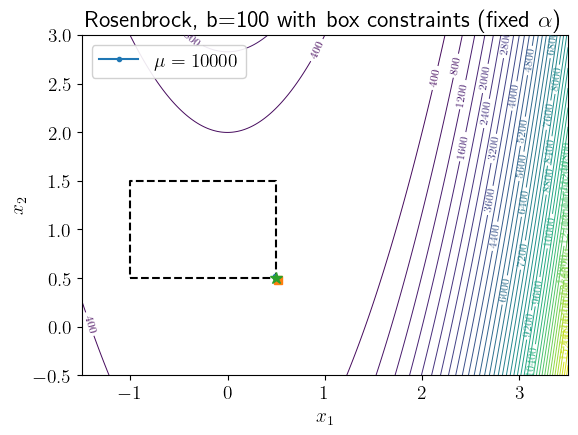

μ =    1.0: iterations = 7956, xmin =[-0.06611511  0.16287297], stop reason =step_tol
μ =   10.0: iterations = 2366, xmin =[-0.14976689  0.40014196], stop reason =step_tol
μ =  100.0: iterations = 1180, xmin =[-0.18316631  0.48810037], stop reason =step_tol
μ = 1000.0: iterations = 317, xmin =[-0.18730499  0.49878597], stop reason =step_tol
μ = 10000.0: iterations = 10000, xmin =[-0.19370372  0.49976063], stop reason =maxiter


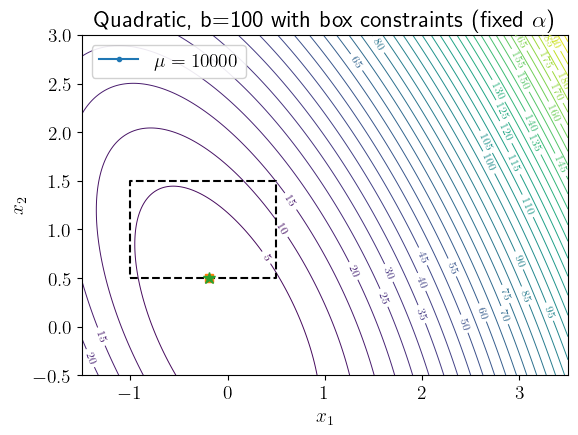

In [105]:
b =100

# Rosenbrock with fixed alpha:
f_base    = lambda x: f_rosen(x, b=b)
grad_base = lambda x: grad_f_rosen(x, b=b)

run_penalty_and_plot(
    f_base, grad_base,
    x0=np.array([2.0, 2.0]),
    mu_list=mu_list,
    alpha_rule=alpha_fixed(1e-4),
    xL=xL, xU=xU,
    xlim=(-1.5, 3.5),
    ylim=(-0.5, 3.0),
    title=rf"Rosenbrock, b={b} with box constraints (fixed $\alpha$)"
)

f_base = lambda x: f_quad(x, b=b, phi = np.pi*0.15)
grad_base = lambda x: grad_f_quad(x, b=b, phi = 0.15*np.pi)

run_penalty_and_plot(
    f_base, grad_base,
    x0=np.array([-1.2,1.0]),
    mu_list=mu_list,
    alpha_rule=alpha_fixed(1e-4),
    xL=xL, xU=xU,
    xlim=(-1.5, 3.5),
    ylim=(-0.5, 3.0),
    title=rf"Quadratic, b={b} with box constraints (fixed $\alpha$)"
)

### Analysis of Results

1) **Qudratic, b=100**

**Observed behaviour**

- For $\mu = 1,10$, and $100$, the method converges via step tolerance to interior points still drifting towards the box.
- For $\mu = 1000$ and $\mu = 10000$ the method again reaches maximum iterations, but the iterates stabilise at the box boundary near $x \approx (-0.19,0.52)
- The final optimisation path is very small since the method appears to have stabilised for much smaller penalty values.

2) **Rosenbrock, b=1**

With $b=1$, the Rosenbrock function is still non-convex but significantly better conditioned. The constrained minimiser lies near $x^* \approx (0.5,0.5)$ on the lower right corner of the box.

**Observed behaviour**

- $\mu = 1,10,100$ converge quickly via the step tolerance, with the minimisers moving steadily toward the boundary.
- $\mu = 1000$ and $\mu = 10000$ hit maxiter, but the iterates stabilise extremely close to $(0.5,0.5)$ which is the constrained minimiser

3) **Rosenbrock, b=100 (ill-conditioned)**

The inner Rosenbrock valley is extremely curved, and the minimiser under the box constraint lies near $x^* \approx (-0.7,0.5)$, different to the $b=1$ case where the minimiser was at (0.5,0.5)

**Observed behaviour**

- For $\mu = 1,10,100$: the method via step tolerance.
- For $\mu = 1000$ and $\mu =10000$: the method hits maxiter failing to converge, but the last iterate does drift towards the correct minimiser.
- The final path $(\mu = 10000)$ shows clear zig-zagging, characteristic of poorly conditioned objectives when using a fixed step size.
- The final point is consistent with the expected boundary solution.


## GSS Box Constraint Gradient Descent

μ =    1.0: iterations = 5, xmin =[1.30199965 1.69662052], stop reason =step_tol
μ =   10.0: iterations = 3508, xmin =[-0.394745    0.17836495], stop reason =step_tol
μ =  100.0: iterations = 10000, xmin =[0.39735063 0.19198752], stop reason =maxiter
μ = 1000.0: iterations = 3075, xmin =[-0.00918829  0.45363898], stop reason =step_tol
μ = 10000.0: iterations = 60, xmin =[-0.00912114  0.49496193], stop reason =step_tol


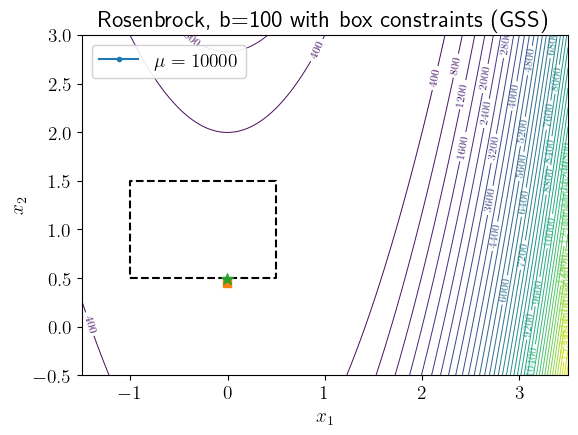

μ =    1.0: iterations = 4, xmin =[0.01101243 0.03625976], stop reason =step_tol
μ =   10.0: iterations = 10000, xmin =[-0.03767478  0.28062767], stop reason =maxiter
μ =  100.0: iterations = 6360, xmin =[-0.20773278  0.4790599 ], stop reason =step_tol
μ = 1000.0: iterations = 306, xmin =[-0.20732201  0.49784227], stop reason =step_tol
μ = 10000.0: iterations = 31, xmin =[-0.20728742  0.49979675], stop reason =step_tol


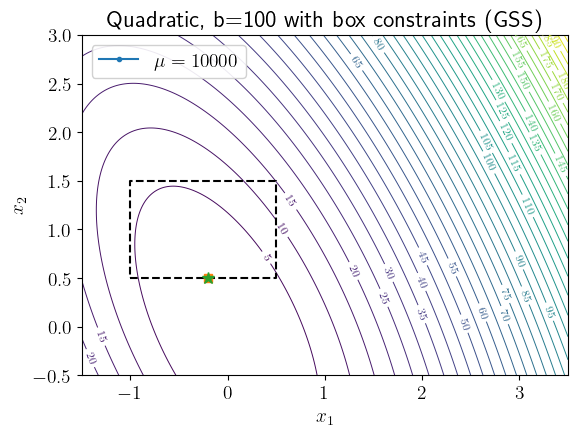

In [ ]:
b = 100
# Rosenbrock with GSS:
f_base    = lambda x: f_rosen(x, b=b)
grad_base = lambda x: grad_f_rosen(x, b=b)

run_penalty_and_plot(
    f_base, grad_base,
    x0=np.array([2.0, 2.0]),
    mu_list=mu_list,
    alpha_rule=alpha_gss(f_base),
    xL=xL, xU=xU,
    xlim=(-1.5, 3.5),
    ylim=(-0.5, 3.0),
    title=rf"Rosenbrock, b={b} with box constraints (GSS)"
)

f_base = lambda x: f_quad(x, b=b, phi = np.pi*0.15)
grad_base = lambda x: grad_f_quad(x, b=b, phi = 0.15*np.pi)

run_penalty_and_plot(
    f_base, grad_base,
    x0=np.array([2.0, 2.0]),
    mu_list=mu_list,
    alpha_rule=alpha_gss(f_base),
    xL=xL, xU=xU,
    xlim=(-1.5, 3.5),
    ylim=(-0.5, 3.0),
    title=rf"Quadratic, b={b} with box constraints (GSS)"
)

### Analysis of Results

**Quadratic, b=100**

Here the method behaves well. For large $\mu$ it quickly converges (31-300 iterations) to a point near $(-0.21, 0.50)$ on the lower edge of the box, matching the expected boundary minimiser.

**Rosenbrock, b=1**

For small $\mu$, the iterates move from the unconstrained minimiser into the box but stop by the step tolerance or maxiter. Once $\mu \geq 100$, the method is pulled into the boundary and converges near $(0.5,0.5)$. Warm starting means the last two $\mu$ values only need 292 and 29 iterations.

**Rosenbrock, b=100 (ill-conditioned)**

GSS always finda a boundary point, but for large $\mu$ it converges near $(-0.01, 0.5)$ rather than the true constrained minimum around $(-0.7,0.5)$ suggested in the brief. The iteration counts are large, reflecting the severe ill-conditioning of $F_{\mu}$

Overall, using GSS inside the penalty method gives more reliable descent than the fixed step size and successfully drives the solution to the box boundary for most cases, but on the ill-conditioned Rosenbrock example it still struggles to identify the “best” boundary point and remains sensitive to the choice of $\mu$.


## Nesterov Box Constraint Gradient Descent

μ =    1.0: iterations = 2252, xmin =[0.75697476 0.5817606 ], stop reason =step_tol
μ =   10.0: iterations = 728, xmin =[0.56134982 0.48314945], stop reason =step_tol
μ =  100.0: iterations = 100, xmin =[0.50789406 0.49745557], stop reason =step_tol
μ = 1000.0: iterations = 16, xmin =[0.50082036 0.4997281 ], stop reason =step_tol
μ = 10000.0: iterations = 404, xmin =[0.49840882 0.49997106], stop reason =step_tol


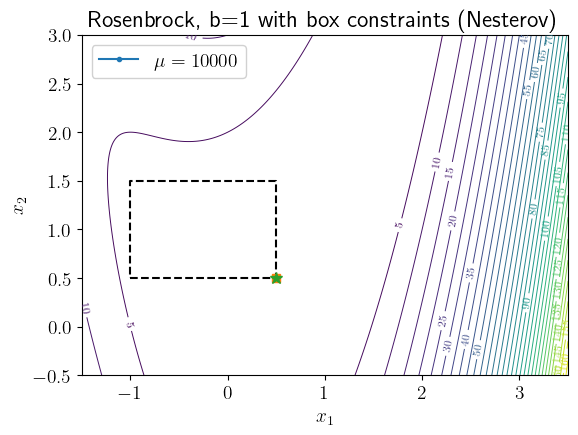

μ =    1.0: iterations = 2454, xmin =[0.06824264 0.19376763], stop reason =step_tol
μ =   10.0: iterations = 660, xmin =[0.14397205 0.42891351], stop reason =grad_tol
μ =  100.0: iterations = 245, xmin =[0.16493174 0.49184246], stop reason =grad_tol
μ = 1000.0: iterations = 16, xmin =[0.16495924 0.49909768], stop reason =step_tol
μ = 10000.0: iterations = 313, xmin =[0.1680508  0.50051664], stop reason =step_tol


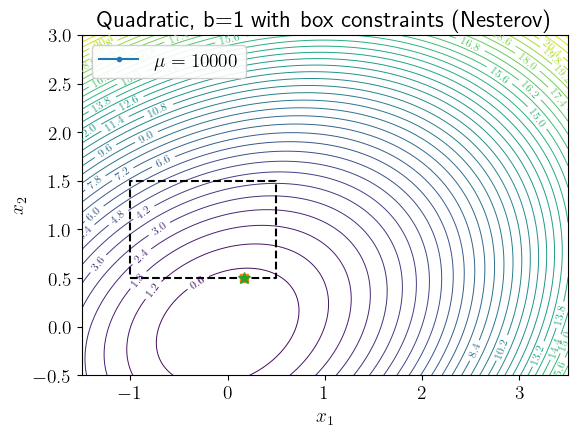

In [ ]:
b=1
# Nesterov step size
L_nest = 1e-4

# Rosenbrock with Nesterov:
f_base    = lambda x: f_rosen(x, b=b)
grad_base = lambda x: grad_f_rosen(x, b=b)

run_penalty_and_plot(
    f_base, grad_base,
    x0=np.array([2.0, 2.0]),
    mu_list=mu_list,
    alpha_rule=None,          # not used when L_nest is given
    xL=xL, xU=xU,
    xlim=(-1.5, 3.5),
    ylim=(-0.5, 3.0),
    title=rf"Rosenbrock, b={b} with box constraints (Nesterov)",
    L_nest=L_nest
)

# Quadratic with Nesterov:
f_base    = lambda x: f_quad(x, b=1, phi=np.pi*0.15)
grad_base = lambda x: grad_f_quad(x, b=1, phi=np.pi*0.15)

run_penalty_and_plot(
    f_base, grad_base,
    x0=np.array([-2.0, 2.0]),
    mu_list=mu_list,
    alpha_rule=None,          # not used when L_nest is given
    xL=xL, xU=xU,
    xlim=(-1.5, 3.5),
    ylim=(-0.5, 3.0),
    title=rf"Quadratic, b={b} with box constraints (Nesterov)",
    L_nest=L_nest
)

### Analysis of Results

**Quadratic, b=100**

- For $\mu =1$ the iterate is outside the box, convergence is slow with 1176 iterations ending due to step tolerance.
- For $\mu = 10$ and $100$, the method reaches points close to the lower boundary in 660 and 245 iterations, now stopping due to the gradient tolerance indicating a small gradient.
- With $\mu = 1000$ only 16 iterations are needed and the solution essentially lies on the boundary.
- The final run with $\mu = 10^4$ (287 iterations stopping due to step tolerance) ends near $(0.168, 0.501), which is approximately the expected minimiser.

Here the combination of convexity and warm starting allows Nesterov to converge to a plausible constrained minimiser, though it does not land at exactly the same boundary point as the GSS and fixed–step solvers.

**Rosenbrock, b=1**

- Small penalties $(\mu = 1,10)$ give points that lie outside the box and stop due to step tolerance after 2252 and 728 iterations respectively.
- For $\mu = 100$ and $1000$, the method rapidly approaches the boundary, only 100 and 16 iterations are needed and the minimisers are already close to $(0.5,0.5)$.
- The final run with $\mu = 10^4$ (404 iterations) ends at $(0.4984, 0.5000)$, approximately the correct constrained minimiser at the right edge of the box.

So in the moderately conditioned case the penalty Nesterov method is reliable and reasonably efficient, especially once $\mu$ is large and the warm start is good.

**Rosenbrock, b=100**

- For $\mu = 1,10,100,1000$, all runs top via the step tolerance in 30-500 iterations, gradually pushing the iterate along teh valley towards the lower boundary of the box.
- For $\mu = 10^4$ the method hits maxiter and stalls near $(0.486, 0.492)$ close to the right-hand side of the boxrather than the true minimiser at $(-0.7,0.5)$.

Thus Nesterov doesn't manage to find the correct constrained minimiser in this ill-conditioned case. The momentum term appears to prevent the method from fully exploring the left side of the box once it has settled into the valley near $x_1 \approx 0.5$.

**Note**: I have been discussing the initial condition $x_0 = (2,2)$. To plot the other initial condition change `x0` in `run_penalty_and_plot()`.


# Task 3 - Higher Dimensional Problem

I have chosen to implement the generalised Rosenbrock function from the appendix of the linked paper in the brief. 

This function extends the 2-dimensional ROsenbrock valley to arbitrary dimension $n$, and is a standard test for gradient descent algorithms due to its narrow curved valleys and string anisotropy.

The cell below defines the function and its gradient without considering constraints.

In [22]:
def f_genrose(x):
    
    x = np.asarray(x)
    n = x.size
    s = 0.0
    for i in range(n-1):
        s += 100.0 * (x[i+1] - x[i]**2)**2 + (1.0 - x[i])**2
    return s


def grad_f_genrose(x):

    x = np.asarray(x)
    n = x.size
    g = np.zeros_like(x, dtype=float)

    # j = 0
    g[0] = -400.0 * x[0] * (x[1] - x[0]**2) - 2.0 * (1.0 - x[0])

    # 0 < j < n-1
    for j in range(1, n-1):
        g[j] = ( 200.0 * (x[j] - x[j-1]**2)
                 - 400.0 * x[j] * (x[j+1] - x[j]**2)
                 - 2.0 * (1.0 - x[j]) )

    # j = n-1
    g[-1] = 200.0 * (x[-1] - x[-2]**2)

    return g

Using the minimiser from the appendix $x^* = (1, 1, 1, \dots , 1)$ with starting point $x_0 = (-1.2, 1, -1.2, 1, 1, 1, \dots, 1)$

In [23]:
# Starting point from the appendix (length 7)
x0_genrose = np.array([-1.2, 1.0, -1.2, 1.0, 1.0, 1.0, 1.0])

# True unconstrained minimiser
xstar_genrose = np.ones_like(x0_genrose)

print("n =", x0_genrose.size)
print("f(x0) =", f_genrose(x0_genrose))
print("f(x*) =", f_genrose(xstar_genrose))

n = 7
f(x0) = 532.4000000000001
f(x*) = 0.0


### helper function to run one method and print metrics

In [50]:
def run_gd_method_1d(name, use_nesterov, 
                     x0, f, grad_f,
                     alpha_rule=None, L_nest=1e-4,
                     maxiter=10000,
                     tol_grad=1e-3, tol_step=1e-7):



    if use_nesterov:
        xmin, path, stop = nesterov_descent(
            f, grad_f,
            x0=x0,
            L=L_nest,
            maxiter=maxiter,
            tol_grad=tol_grad,
            tol_step=tol_step
        )

    else:
        xmin, path, stop = gradient_descent(
            f, grad_f,
            x0=x0,
            alpha_rule=alpha_rule,
            maxiter=maxiter,
            tol_grad=tol_grad,
            tol_step=tol_step
        )

    path = np.array(path)
    iters = len(path) - 1
    f_end = f(xmin)
    err_x = np.linalg.norm(xmin - xstar_genrose)


    print(f"{name:10s} | iters = {iters:5d} | "
          f"f_end = {f_end:.3e} | ||x - x*|| = {err_x:.3e} | stop = {stop}")

    return xmin, path, stop

### Run the three methods for the step size on GENROSE

In [ ]:
# Step rules
alpha_fixed_rule = alpha_fixed(1e-4)          
alpha_gss_rule   = alpha_gss(f_genrose)       
L_nest           = 1e-4                       

print("Generalized Rosenbrock (GENROSE), n =", x0_genrose.size)
print("Starting from x0 =", x0_genrose)

xmin_fix, path_fix, stop_fix  = run_gd_method_1d(
    "fixed α",
    use_nesterov=False,
    x0=x0_genrose,
    f=f_genrose,
    grad_f=grad_f_genrose,
    alpha_rule=alpha_fixed_rule
)

xmin_gss, path_gss, stop_gss  = run_gd_method_1d(
    "GSS",
    use_nesterov=False,
    x0=x0_genrose,
    f=f_genrose,
    grad_f=grad_f_genrose,
    alpha_rule=alpha_gss_rule
)

xmin_nest, path_nest, stop_nest = run_gd_method_1d(
    "Nesterov",
    use_nesterov=True,
    x0=x0_genrose,
    f=f_genrose,
    grad_f=grad_f_genrose,
    L_nest=L_nest
)

Generalized Rosenbrock (GENROSE), n = 7
Starting from x0 = [-1.2  1.  -1.2  1.   1.   1.   1. ]
fixed α    | iters = 10000 | f_end = 1.339e+00 | ||x - x*|| = 1.516e+00 | stop = maxiter
GSS        | iters = 10000 | f_end = 1.273e-06 | ||x - x*|| = 2.258e-03 | stop = maxiter
Nesterov   | iters =  2686 | f_end = 5.873e-07 | ||x - x*|| = 1.535e-03 | stop = grad_tol


## Plots


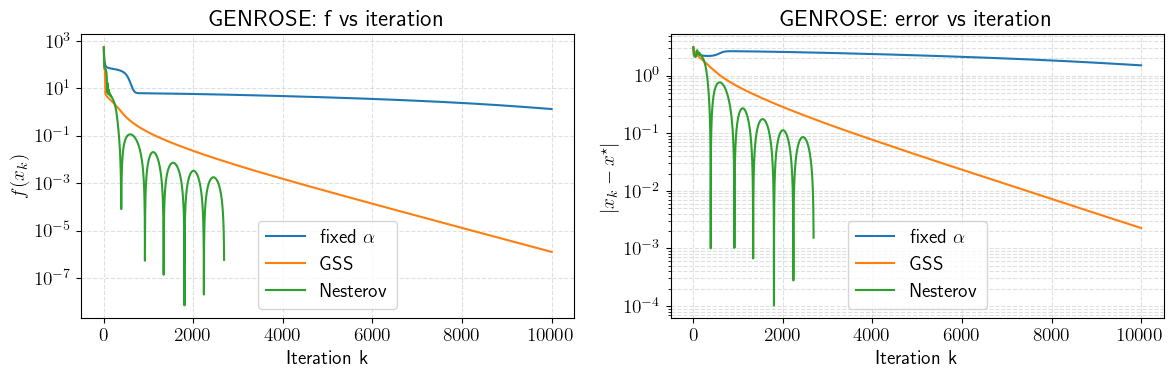

In [326]:
def plot_f_and_err_vs_iter(paths, labels, f, x_star, 
                           title_f="f vs iteration",
                           title_err="error vs iteration"):
    """
    paths  : list of arrays (each path is K x n)
    labels : list of method names
    f      : objective function
    x_star : true minimiser for error computation
    """

    fig, axes = plt.subplots(1, 2, figsize=(12,4))

    # ---- Left subplot: f(x_k) vs iteration ----
    ax = axes[0]
    for path, label in zip(paths, labels):
        fk = [f(x) for x in path]
        ax.semilogy(fk, label=label)
    ax.set_xlabel("Iteration k")
    ax.set_ylabel(r"$f(x_k)$")
    ax.set_title(title_f)
    ax.grid(True, which="both", ls="--", alpha=0.4)
    ax.legend()

    # ---- Right subplot: error vs iteration ----
    ax = axes[1]
    for path, label in zip(paths, labels):
        err = [np.linalg.norm(x - x_star) for x in path]
        ax.semilogy(err, label=label)
    ax.set_xlabel("Iteration k")
    ax.set_ylabel(r"$|x_k - x^\star|$")
    ax.set_title(title_err)
    ax.grid(True, which="both", ls="--", alpha=0.4)
    ax.legend()

    plt.tight_layout()
    plt.show()

plot_f_and_err_vs_iter(
    [path_fix, path_gss, path_nest],
    [r"fixed $\alpha$", "GSS", "Nesterov"],
    f_genrose,
    xstar_genrose,
    title_f="GENROSE: f vs iteration",
    title_err="GENROSE: error vs iteration"
)



## Convergence Behaviour

With a tighter step tolerance `tol_step = 1e-7`, the true behaviour of Nesterov acceleration becomes visible. The method exhibits the characteristric oscillatory behaviour that is well-known in narrow curved valleys such as those of the Rosenbrock family.

Nesterov eventually reduces the objective value significantly, though not monotonically, and is not as effective as GSS. In contrast, the GSS line search method shows smooth, stable, monotonic convergence, that terminates due to reaching the maximum number of iterations rather than due to a small gradient. The same is true for the fixed step size method, which barely decreases the objective at all due to poor conditioning in the GENROSE landscape. 

GSS remains the most reliable method, while Nesterov accelerates aggresively but with oscilatory dynamics, and fixed $\alpha$ performs poorly.



# Task 4 - Some Maths

Consider the fixed point iteration

$$
x_{k+1} = F(x_k)
$$

for some function $F$ with a fixed point $x^*$, i.e.

$$
F(x^*) = x^* \quad \text{and} \quad |DF(x)| < q < 1 \, \, \text{for} \, \, |x-x^*| < d
$$

for some $d>0$.

1) Show that if $|x_0 -x^*| < d$ then $x_k \to x^*$ for $k \to \infty$.
2) Show that if $F'(x^*) = 0$ and $|F''(x)| < M$ for $|x-x^*| < d$ then the convergence of $x_k$ to $x^*$ is at least of second order.

## Answers 

### Convergence under contraction 

Let $x$ satisfy $|x-x^*|< d$. By the Mean Value Theorem, there exists some $\xi$ between $x$ and $x^*$ such that

$$
F(x) - F(x^*) = F(\xi)(x-x^*).
$$

Using $F(x^*) = x^*$, we get

$$
|F(x) - x^*| = |F'(\xi)||x-x^*| \leq q|x-x^*|
$$

So on the ball $|x-x^*| < d$, $F$ is a contraction with Lipschitz constant $q<1$.

Suppose $|x_0 - x^*| < d$. Then using the contraction inequality,

$$
|x_1 - x^*| = |F(x_0) - x^*| \leq q|x_0 - x^*| < qd < d.
$$

By induction, if $|x_k -x^*| < d$, then 

$$
|x_{k+1} - x^*| = |F(x_k) - x^*| \leq q|x_k -x^*| < qd < d.
$$

Hence $|x_k - x^*| < d $ for all $k$. So all iterates stay in the region where the estimate holds.

Applying the contraction estimate repeatedly,

$$
|x_{k+1} -x^*| \leq q|x_k - x^*| \leq q^2|x_{k+1} - x^*| \leq \dots \leq q^{k+1}|x_0 -x^*|.
$$

Since $0< q < 1$, then $q^{k+1} \to 0 $ as $ k \to \infty$. Therefore

$$
|x_k - x^*| \leq q^k |x_0 -x^*| \to 0
$$

so $x_k \to x^* \quad \square$.

### Second order convergence 

The aim is to show the convergence is at least second order:

$$
|x_{k+1} -x^*| \leq C|x_k - x^*|^2
$$

for some constant $C$ and $x_k$ close enough to $x^*$.

Let $e_k = x_k -x^*$ denote the error.

Using Taylor's theorem for $F$ about $x^*$, for any $x$ with $|x-x^*| < d$ there exists $\xi$ between $x$ and $x^*$ such that

$$
F(x) = F(x^*) + F'(x^*)(x-x^*) + \frac{1}{2} F''(\xi)(x-x^*)^2
$$

Using $F(x^*) = x^*$ and $F'(x^*) = 0$,

$$
F(x) - x^* = \frac{1}{2} F''(\xi)(x-x^*)^2.
$$

Now set $x=x_k$ and recall that $x_{k+1} = F(x_k)$. Then

$$
e_{k+1} = x_{k+1} - x^* = F(x_k) - x^* = \frac{1}{2}F''(\xi_k)e^2_k
$$

for some $\xi_k$ between $x_k$ and $x^*$.

Taking absolute values and using $|F(\xi_k)| \leq M$,

$$
|e_{k+1}| \leq \frac{M}{2} |e_k|^2.
$$

Thus, as soon as $x_k$ is sufficiently close to $x^*$ so that we remain in the region $|x-x^*| < d$, the error satisfies

$$
|x_{k+1} -x^*| \leq C|x_k -x|^2, \quad \quad C=\frac{M}{2} \quad \square 
$$

which proves second-order convergence.

## Newtons method as a fixed point iteration

Want to solve the equation $f(x)=0$ for a smooth scalar function $f:\mathbb{R} \to \mathbb{R}$

Let $x^*$ be a **simple root** of $f$:

$$
f(x^*) = 0, \qquad f'(x^*) \neq 0. 
$$

Assume that in a neighbourhood of $x^*$:

$$
f'(x) > m > 0, \qquad |f''(x)| \leq M.
$$

These assumptions guranatee that $f'$ doesn't vanish near the root and that $f''$ is bounded.

The Newton iteration is

$$
x_{k+1} = x_k - \frac{f(x_k)}{f'(x_k)}.
$$

Define the map

$$
F(x) = x - \frac{f(x)}{f'(x)}.
$$

Then Newton's method is the fixed point iteration:

$$
x_{k+1} = F(x_k)
$$

since $f'(x^*) = 0$,

$$
F(x^*) = x^*,
$$

so $x^*$ is a fixed point of $F$.



### Derivative of $F(x)$

To use the theory from the previous questions, we need to prove that $F'(x^*) = 0$ and that $F''$ is bounded.

Differentiate:

$$
F(x) = x - \frac{f(x)}{f'(x)},
$$

using the quotient rule,

$$
\frac{d}{dx} (\frac{f(x)}{f'(x)}) = \frac{f'(x)f'(x) - f(x)f''(x)}{(f'(x))^2} = 1 - \frac{f(x)f''(x)}{f'(x)^2}.
$$

Hence,

$$
F'(x) = 1 - [1 - \frac{f(x)f''(x)}{f'(x)^2}] = \frac{f(x)f''(x)}{f'(x)^2}.
$$

At the root $x^*$, where $f(x^*) = 0$,

$$
F'(x^*) = 0.
$$

This matches the condition in the second question: a fixed point mapping with vanishing derivative at the fixed point.


### Bound on the second derivative of $F$

Because $f(x)>m>0$ and $|f''(x)| \leq M$ near $x^*$, the expression for $F'$ is smooth, and $F$ is twice continuously differentiable in a neighbourhood of the root.

Hence there exists a constant $C>0$ such that

$$
|F''(x)|\leq C, \qquad \text{for all} \, \, x \, \, \text{near} \, \,  x^*
$$

This is the final assumption required from question $2$ needed to prove the convergence is at least of second order.